In [1]:
from system_functions import *
import matplotlib.pyplot as plt

Initialize system with: 
chemical potential (Thomas-Fermi) --> 1.1616532425498978 
size in x --> 33.882458170185174 
size in z --> 377.3648385177436 
size in kx --> 5.910939365360629 
size in kz --> 4.245791048323807 
grid points nx, nz--> 64, 512 
Thomas-Fermi radii Rx, Rz--> 22.588305446790116, 150.94593540709744 
grid spacing dx, dz --> 0.20588104938208654, 0.7370407002299679 
healing length -- > 1.2273848824670373
creating (x, z) <-> (kx, kz) transformation matrix
creating (x, z) <-> (kx, kz) transformation matrix ---> done


In [2]:
g_eff

np.float64(0.7752235992527382)

In [3]:
g_twa

np.float64(0.7772065851447946)

In [2]:
psi_gs = get_ground_state(5000, 0.02, delta=0, omega=0.5)

In [31]:
n_z = (dv * np.abs(psi_gs)**2).reshape((nx, nz)).sum(axis=0) / dz
n_z_tf = (dv * (mu - U) * (mu > U)).reshape((nx, nz)).sum(axis=0) / dz / g_eff / n_atoms

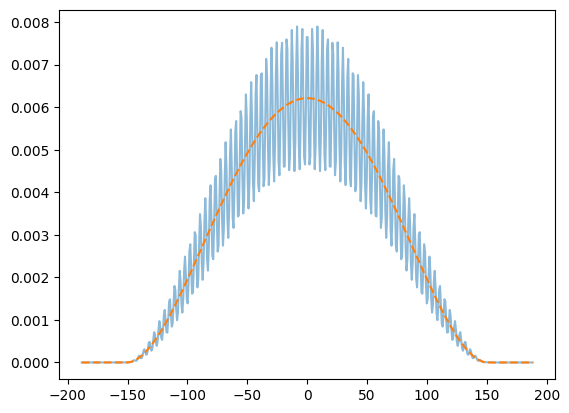

In [44]:
plt.plot(z, n_z, 'tab:blue', alpha=0.5)
plt.plot(z, n_z_tf*(1 + 0.0*np.cos(2*k_l*z)), '--', color='tab:orange')
# plt.xlim(-10, 10)

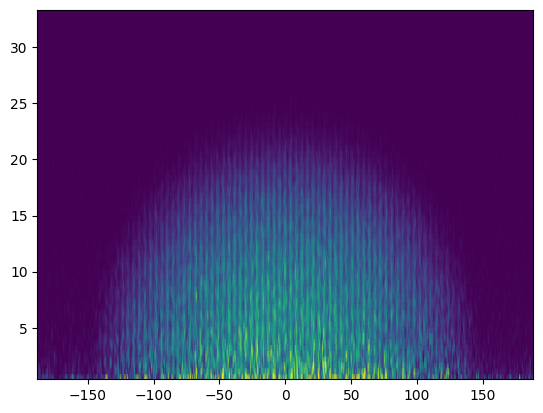

In [48]:
# np.random.seed(seed=1)
noise = np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk)) + 1j*np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk))
psik_0 = (fourier_transform(psi_gs) + noise)
psik_0[(kx_**2 + kz_**2).reshape(nx*nz) > (kx_**2 + kz_**2).max()/2] = 0
psi_0 = ifourier_transform(psik_0)

plt.pcolormesh(z, x, (np.abs(psi_0)**2).reshape((nx , nz)), vmin=0, vmax=1.5e-5, shading='gouraud')

ValueError: operands could not be broadcast together with shapes (200,) (31,) (200,) 

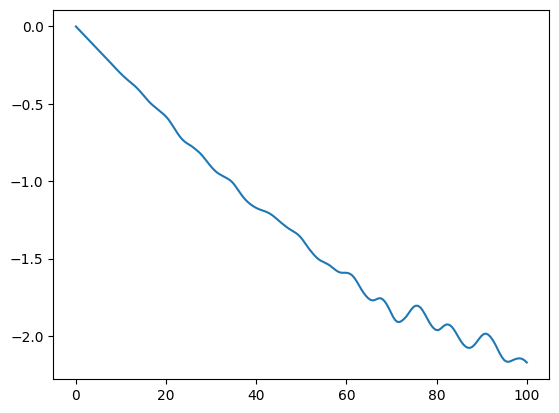

In [3]:
from scipy.integrate import solve_ivp
def delta_f(t):
    return 0
def omega_f(t):
    return 0.5
t_axis = np.linspace(0, 100, 200)

sol1 = solve_ivp(fun=sequence_ramp,
                  y0=psi_gs*np.exp(+1j*0*z_.reshape(nx*nz)),
                  method='RK45',
                  t_span=(t_axis[0], t_axis[-1]),
                  t_eval=t_axis,
                  args=(delta_f, omega_f, g_twa),
                  atol=1e-7,
                  rtol=1e-7)
plt.plot(t_axis, (np.abs(sol1.y)**2 * (dv*z_.reshape(nx*nz))[:, None]).sum(axis=0))
n_twa = 0*(np.abs(sol1.y)**2 * dv[:, None]).sum(axis=0)
for _ in range(1):
    noise = np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk)) + 1j*np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk))
    psik_0 = (fourier_transform(psi_gs) + noise)
    psik_0[(kx_**2 + kz_**2).reshape(nx*nz) > (kx_**2 + kz_**2).max()/2] = 0
    psi_0 = ifourier_transform(psik_0)
    sol2 = solve_ivp(fun=sequence_ramp,
                      y0=psi_0*np.exp(+1j*0*z_.reshape(nx*nz)),
                      method='RK45',
                      t_span=(t_axis[0], t_axis[-1]),
                      t_eval=t_axis,
                      args=(delta_f, omega_f, g_twa),
                      atol=1e-7,
                      rtol=1e-7)
    n_twa += ((np.abs(sol2.y)**2 * (dv*z_.reshape(nx*nz))[:, None]).sum(axis=0) - ((kx_**2 + kz_**2).reshape(nx*nz) < (kx_**2 + kz_**2).max()/2).sum()/2/n_atoms) / 5

plt.plot(t_axis, n_twa)
plt.hlines(0, xmin=0, xmax=100, linestyle='--', color='k', alpha=0.5)

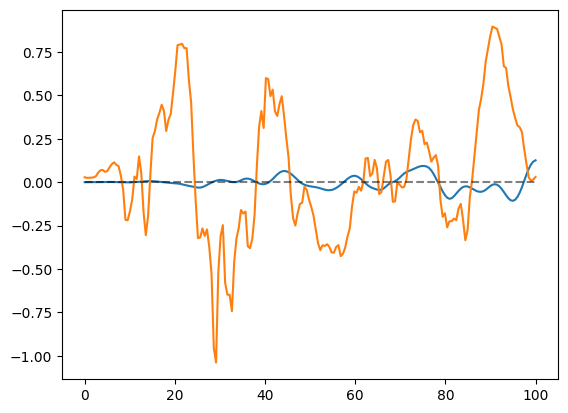

In [73]:
from scipy.integrate import solve_ivp
def delta_f(t):
    return 0
def omega_f(t):
    return 0
t_axis = np.linspace(0, 100, 200)

sol1 = solve_ivp(fun=sequence_ramp,
                  y0=psi_gs*np.exp(+1j*0*z_.reshape(nx*nz)),
                  method='RK45',
                  t_span=(t_axis[0], t_axis[-1]),
                  t_eval=t_axis,
                  args=(delta_f, omega_f),
                  atol=1e-7,
                  rtol=1e-7)
plt.plot(t_axis, (np.abs(sol1.y)**2 * (dv*z_.reshape(nx*nz))[:, None]).sum(axis=0))
n_twa = 0*(np.abs(sol1.y)**2 * dv[:, None]).sum(axis=0)
for _ in range(5):
    noise = np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk)) + 1j*np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk))
    psik_0 = (fourier_transform(psi_gs) + noise)
    psik_0[(kx_**2 + kz_**2).reshape(nx*nz) > 100] = 0
    psi_0 = ifourier_transform(psik_0)
    sol2 = solve_ivp(fun=sequence_ramp,
                      y0=psi_0*np.exp(+1j*0*z_.reshape(nx*nz)),
                      method='RK45',
                      t_span=(t_axis[0], t_axis[-1]),
                      t_eval=t_axis,
                      args=(delta_f, omega_f),
                      atol=1e-7,
                      rtol=1e-7)
    n_twa += ((np.abs(sol2.y)**2 * (dv*z_.reshape(nx*nz))[:, None]).sum(axis=0) - ((kx_**2 + kz_**2).reshape(nx*nz) < 100).sum()/2/n_atoms)/10

plt.plot(t_axis, n_twa)
plt.hlines(0, xmin=0, xmax=100, linestyle='--', color='k', alpha=0.5)

In [23]:
np.random.seed(seed=1)
noise = np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk)) + 1j*np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk))
psik_0 = (fourier_transform(psi_gs) + noise)
psik_0[(kx_**2 + kz_**2).reshape(nx*nz) > 5] = 0
psi_0 = ifourier_transform(psik_0)

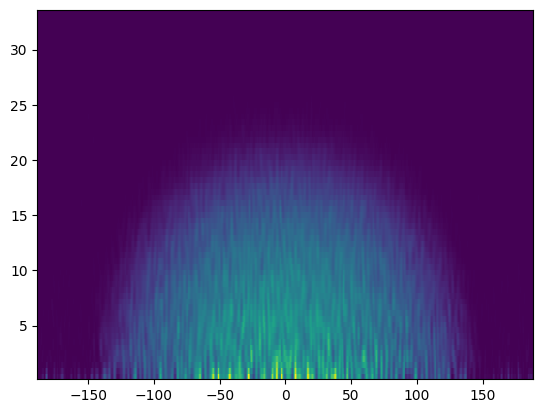

In [24]:
plt.pcolormesh(z, x, (np.abs(psi_0)**2).reshape((nx , nz)))

In [22]:
print((np.abs(psi_gs)**2 * dv).sum())
print((np.abs(psi_0)**2 * dv).sum() - ((kx_**2 + kz_**2).reshape(nx*nz) < 5).sum()/2/n_atoms)

1.0000000000000002
1.0154863526294682


In [21]:
((kx_**2 + kz_**2).reshape(nx*nz) < 5).sum()/2/n_atoms

np.float64(0.013001049806328832)

In [11]:
((kx_**2 + kz_**2).reshape(nx*nz) > 10).sum()

np.int64(22678)

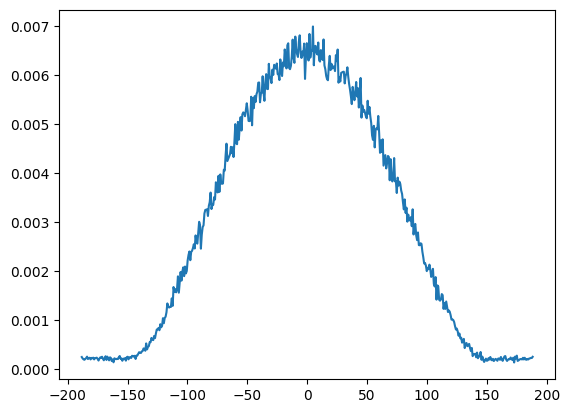

In [29]:
plt.plot(z, (np.abs(psi_0)**2*dv).reshape((nx, nz)).sum(axis=0)/dz)
# plt.xlim(-30, 30)
# plt.ylim(0.005, 0.007)

(0.005, 0.007)

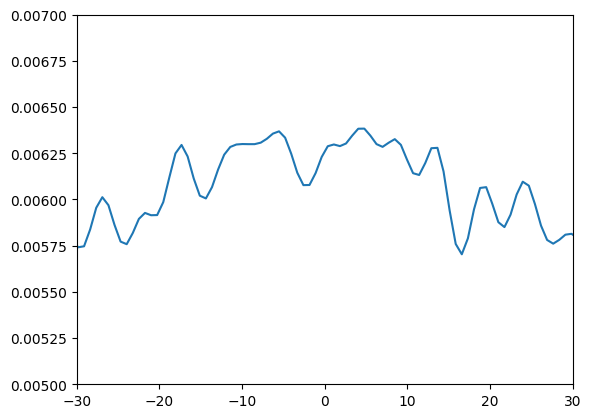

In [7]:
plt.plot(z, (np.abs(psi_0)**2*dv).reshape((nx, nz)).sum(axis=0)/dz)
plt.xlim(-30, 30)
plt.ylim(0.005, 0.007)

In [16]:
a = np.eye((nx*nz))
result = np.apply_along_axis(H_single_particle, axis=0, arr=a, detuning=0, lattice_strength=0)
# H_single_particle()

In [20]:
np.diag(np.array([1, 2, 3]))

array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 3]])

In [23]:
chemical = (psi_gs.conj().T @ ((result + g*n_atoms*np.diag(np.abs(psi_gs)**2)) @ (dv*psi_gs)))

In [25]:
np.eye(nx*nz)*chemical.real

np.float64(1.1345683143276017)

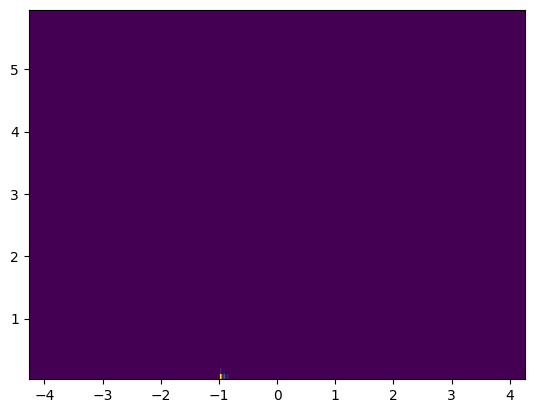

In [51]:
plt.pcolormesh(kz_, kx_, (np.abs(psik_0)**2).reshape((nx , nz)))

In [56]:
(kx_**2 + kz_**2).max()

np.float64(53.107609243688515)

In [42]:
psi_gs.max()

np.complex128(0.0027678374621918174-8.461146759746697e-05j)

In [29]:
len(kx)

64

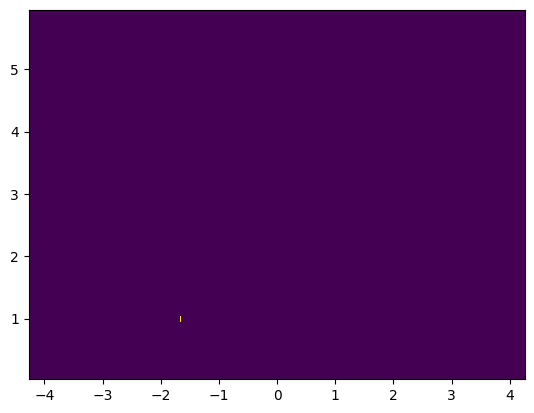

In [27]:
plt.pcolormesh(kz_, kx_, a.reshape((nx, nz)).real)

In [102]:
50/(4*f_recoil)*1e3

6.377551020408164

In [5]:
np.arange(60)

np.float64(0.6638018528856557)

In [6]:
(np.arange(60)*1e-3 / t_unit) * gn * 0.67

array([  0.        ,   5.47708149,  10.95416298,  16.43124448,
        21.90832597,  27.38540746,  32.86248895,  38.33957045,
        43.81665194,  49.29373343,  54.77081492,  60.24789641,
        65.72497791,  71.2020594 ,  76.67914089,  82.15622238,
        87.63330388,  93.11038537,  98.58746686, 104.06454835,
       109.54162985, 115.01871134, 120.49579283, 125.97287432,
       131.44995581, 136.92703731, 142.4041188 , 147.88120029,
       153.35828178, 158.83536328, 164.31244477, 169.78952626,
       175.26660775, 180.74368924, 186.22077074, 191.69785223,
       197.17493372, 202.65201521, 208.12909671, 213.6061782 ,
       219.08325969, 224.56034118, 230.03742267, 235.51450417,
       240.99158566, 246.46866715, 251.94574864, 257.42283014,
       262.89991163, 268.37699312, 273.85407461, 279.3311561 ,
       284.8082376 , 290.28531909, 295.76240058, 301.23948207,
       306.71656357, 312.19364506, 317.67072655, 323.14780804])

In [98]:
t_unit

8.120150157749762e-05

In [109]:
t_axis_ms = (1/20)*np.arange(1000)/(4*f_recoil)*1e3

In [110]:
t_axis_ms

array([0.        , 0.00637755, 0.0127551 , 0.01913265, 0.0255102 ,
       0.03188776, 0.03826531, 0.04464286, 0.05102041, 0.05739796,
       0.06377551, 0.07015306, 0.07653061, 0.08290816, 0.08928571,
       0.09566327, 0.10204082, 0.10841837, 0.11479592, 0.12117347,
       0.12755102, 0.13392857, 0.14030612, 0.14668367, 0.15306122,
       0.15943878, 0.16581633, 0.17219388, 0.17857143, 0.18494898,
       0.19132653, 0.19770408, 0.20408163, 0.21045918, 0.21683673,
       0.22321429, 0.22959184, 0.23596939, 0.24234694, 0.24872449,
       0.25510204, 0.26147959, 0.26785714, 0.27423469, 0.28061224,
       0.2869898 , 0.29336735, 0.2997449 , 0.30612245, 0.3125    ,
       0.31887755, 0.3252551 , 0.33163265, 0.3380102 , 0.34438776,
       0.35076531, 0.35714286, 0.36352041, 0.36989796, 0.37627551,
       0.38265306, 0.38903061, 0.39540816, 0.40178571, 0.40816327,
       0.41454082, 0.42091837, 0.42729592, 0.43367347, 0.44005102,
       0.44642857, 0.45280612, 0.45918367, 0.46556122, 0.47193

In [111]:
t_axis_ms*1e-3/t_unit

array([ 0.        ,  0.07853982,  0.15707963,  0.23561945,  0.31415927,
        0.39269908,  0.4712389 ,  0.54977871,  0.62831853,  0.70685835,
        0.78539816,  0.86393798,  0.9424778 ,  1.02101761,  1.09955743,
        1.17809725,  1.25663706,  1.33517688,  1.41371669,  1.49225651,
        1.57079633,  1.64933614,  1.72787596,  1.80641578,  1.88495559,
        1.96349541,  2.04203522,  2.12057504,  2.19911486,  2.27765467,
        2.35619449,  2.43473431,  2.51327412,  2.59181394,  2.67035376,
        2.74889357,  2.82743339,  2.9059732 ,  2.98451302,  3.06305284,
        3.14159265,  3.22013247,  3.29867229,  3.3772121 ,  3.45575192,
        3.53429174,  3.61283155,  3.69137137,  3.76991118,  3.848451  ,
        3.92699082,  4.00553063,  4.08407045,  4.16261027,  4.24115008,
        4.3196899 ,  4.39822972,  4.47676953,  4.55530935,  4.63384916,
        4.71238898,  4.7909288 ,  4.86946861,  4.94800843,  5.02654825,
        5.10508806,  5.18362788,  5.26216769,  5.34070751,  5.41

In [112]:
np.arange(50)*pi/2

array([ 0.        ,  1.57079633,  3.14159265,  4.71238898,  6.28318531,
        7.85398163,  9.42477796, 10.99557429, 12.56637061, 14.13716694,
       15.70796327, 17.27875959, 18.84955592, 20.42035225, 21.99114858,
       23.5619449 , 25.13274123, 26.70353756, 28.27433388, 29.84513021,
       31.41592654, 32.98672286, 34.55751919, 36.12831552, 37.69911184,
       39.26990817, 40.8407045 , 42.41150082, 43.98229715, 45.55309348,
       47.1238898 , 48.69468613, 50.26548246, 51.83627878, 53.40707511,
       54.97787144, 56.54866776, 58.11946409, 59.69026042, 61.26105675,
       62.83185307, 64.4026494 , 65.97344573, 67.54424205, 69.11503838,
       70.68583471, 72.25663103, 73.82742736, 75.39822369, 76.96902001])

In [113]:
1000/50

20.0

In [115]:
dphi = np.abs(0.9922 - 0.99850)

In [116]:
0.99850 + dphi

np.float64(1.0048000000000001)

In [7]:
gn

np.float64(0.6638018528856557)

In [8]:
0.6638 * 0.67

0.444746